In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DB = pd.read_csv("C:/Users/editing3/OneDrive/Desktop/ecommerce_dataset.csv.xls",encoding = "unicode_escape")
DB.shape

(50000, 15)

In [ ]:
DB.head()

,Order_ID,Customer_ID,Age,Gender,City,Category,Product,Price,Quantity,Discount,Profit,Order_Date,Payment_Method,Order_Status,Shipping_Days
0,100000,1235,43,Male,Bangalore,Sports,Cricket Bat,8869,2,0.09,1182.46,2024-05-21,Credit Card,Returned,6
1,100001,13172,45,Female,Hyderabad,Books,Self Help,233,1,0.12,14.97,2022-01-29,UPI,Delivered,5
2,100002,6192,64,Male,Kolkata,Grocery,Rice,587,3,0.23,391.08,2022-02-12,Cash on Delivery,Delivered,9
3,100003,18289,48,Female,Ahmedabad,Books,Biography,1389,4,0.27,1121.59,2023-02-04,Credit Card,Delivered,7
4,100004,11955,41,Female,Patna,Books,Novel,919,5,0.21,902.60,2022-10-19,Net Banking,Cancelled,7


In [ ]:
DB.tail()

,Order_ID,Customer_ID,Age,Gender,City,Category,Product,Price,Quantity,Discount,Profit,Order_Date,Payment_Method,Order_Status,Shipping_Days
49995,149995,1802,19,Male,Lucknow,Sports,Yoga Mat,731,5,0.31,623.42,2023-07-27,UPI,Delivered,1
49996,149996,11221,48,Female,Chennai,Sports,Yoga Mat,11882,1,0.34,2888.23,2022-10-15,UPI,Cancelled,1
49997,149997,13237,45,Male,Lucknow,Grocery,Oil,1088,5,0.16,669.96,2024-01-17,Credit Card,Delivered,7
49998,149998,1508,30,Male,Lucknow,Sports,Yoga Mat,2241,3,0.33,1160.94,2022-01-07,UPI,Shipped,3
49999,149999,11836,20,Male,Chennai,Home Decor,Wall Art,5268,3,0.01,1805.44,2022-04-21,Cash on Delivery,Shipped,4


In [ ]:
DB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        50000 non-null  int64  
 1   Customer_ID     50000 non-null  int64  
 2   Age             50000 non-null  int64  
 3   Gender          50000 non-null  object 
 4   City            50000 non-null  object 
 5   Category        50000 non-null  object 
 6   Product         50000 non-null  object 
 7   Price           50000 non-null  int64  
 8   Quantity        50000 non-null  int64  
 9   Discount        50000 non-null  float64
 10  Profit          50000 non-null  float64
 11  Order_Date      50000 non-null  object 
 12  Payment_Method  50000 non-null  object 
 13  Order_Status    50000 non-null  object 
 14  Shipping_Days   50000 non-null  int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 5.7+ MB


In [ ]:
DB.columns

Index(['Order_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Category',
       'Product', 'Price', 'Quantity', 'Discount', 'Profit', 'Order_Date',
       'Payment_Method', 'Order_Status', 'Shipping_Days'],
      dtype='object')

In [ ]:
DB.describe()

,Order_ID,Customer_ID,Age,Price,Quantity,Discount,Profit,Shipping_Days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,10490.301160,40.997980,8678.414960,3.012780,0.174827,3928.967782,4.967700
std,14433.901067,5484.501952,13.561815,16004.105445,1.414955,0.101414,8962.010422,2.587669
min,100000.000000,1000.000000,18.000000,50.000000,1.000000,0.000000,5.310000,1.000000
25%,112499.750000,5743.000000,29.000000,1106.000000,2.000000,0.090000,355.702500,3.000000
50%,124999.500000,10502.000000,41.000000,2637.000000,3.000000,0.170000,970.380000,5.000000
75%,137499.250000,15231.000000,53.000000,7376.000000,4.000000,0.260000,2948.835000,7.000000
max,149999.000000,19999.000000,64.000000,79981.000000,5.000000,0.350000,98316.830000,9.000000


In [ ]:
# find the total revenue
DB["Revenue"] = DB["Price"] * DB["Quantity"]
print("Total Revenue:",DB["Revenue"].sum())

Total Revenue: 1308327416


In [ ]:
# top 10 cities by Sale
city_sales = DB.groupby("City")["Revenue"].sum()
city_sales.sort_values(ascending = False).head(10)

City
Mumbai       134989377
Ahmedabad    134135658
Lucknow      133959099
Chennai      133271102
Delhi        131883223
Kolkata      129821263
Bangalore    129033571
Patna        127949074
Pune         127674330
Hyderabad    125610719
Name: Revenue, dtype: int64

In [ ]:
# Most Sold product category
category_sale = DB.groupby("Category")["Quantity"].sum()
category_sale.sort_values(ascending = False)

Category
Clothing       21804
Home Decor     21687
Sports         21681
Electronics    21491
Beauty         21361
Grocery        21313
Books          21302
Name: Quantity, dtype: int64

In [ ]:
# Payment Method used by custome
DB["Payment_Method"].value_counts()

Payment_Method
Net Banking         10088
Debit Card          10086
Credit Card          9983
UPI                  9979
Cash on Delivery     9864
Name: count, dtype: int64

C:\Users\editing3\AppData\Local\Temp\ipykernel_7724\3961219554.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= "Payment_Method", data=DB, palette="Set2")


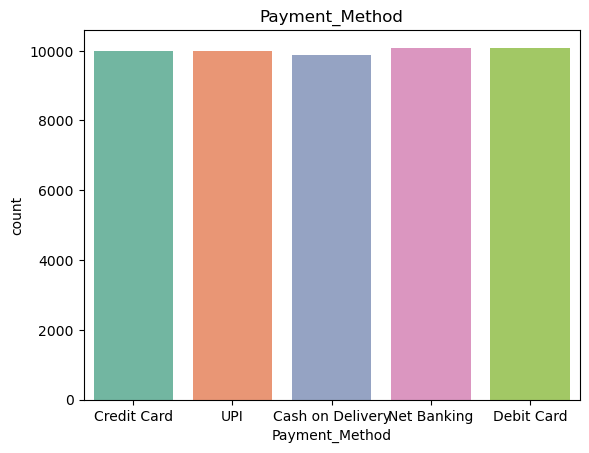

In [ ]:
sns.countplot(x= "Payment_Method", data=DB, palette="Set2")
plt.title("Payment_Method")
plt.show()


In [ ]:
# Top 5 Products by Revenue
product_sales = DB.groupby("Product")["Revenue"].sum()
product_sales.sort_values(ascending = False).head(5)

Product
Mouse         186831426
Headphones    180053742
Keyboard      175606618
Laptop        171429582
Smartphone    170086929
Name: Revenue, dtype: int64

In [ ]:
# Total Orders by City
DB["City"].value_counts()

City
Bangalore    5074
Hyderabad    5034
Mumbai       5029
Lucknow      5022
Patna        5016
Kolkata      5000
Ahmedabad    4982
Pune         4963
Chennai      4963
Delhi        4917
Name: count, dtype: int64

In [ ]:
# total Order_Status of Products
DB["Order_Status"].value_counts()

Order_Status
Delivered    35121
Returned      5016
Shipped       4939
Cancelled     4924
Name: count, dtype: int64

C:\Users\editing3\AppData\Local\Temp\ipykernel_7724\1484735775.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= "Order_Status", data=DB, palette="Set1")


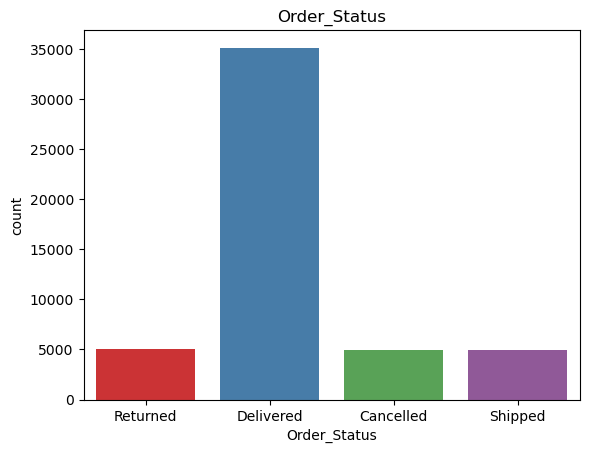

In [ ]:
sns.countplot(x= "Order_Status", data=DB, palette="Set1")
plt.title("Order_Status")
plt.show()

In [ ]:
DB["Gender"].value_counts()

Gender
Male      25136
Female    24864
Name: count, dtype: int64

In [ ]:
DB.groupby("Gender")["Revenue"].sum()

Gender
Female    651143354
Male      657184062
Name: Revenue, dtype: int64

In [ ]:
age_revenue = DB.groupby("Age")["Revenue"].sum()
age_revenue.sort_values(ascending=False).head(10)

Age
39    32427638
34    31383599
38    31287061
56    31057262
28    30838955
30    30828810
48    30588125
46    29963578
40    29749927
60    29606961
Name: Revenue, dtype: int64

In [ ]:
DB.groupby("Category")["Profit"].sum()

Category
Beauty         6.719458e+06
Books          2.669392e+06
Clothing       8.728219e+06
Electronics    1.325957e+08
Grocery        3.310602e+06
Home Decor     1.726465e+07
Sports         2.516033e+07
Name: Profit, dtype: float64

In [ ]:
DB.groupby("Payment_Method")["Revenue"].sum()

Payment_Method
Cash on Delivery    257177646
Credit Card         256431868
Debit Card          271628820
Net Banking         257189691
UPI                 265899391
Name: Revenue, dtype: int64

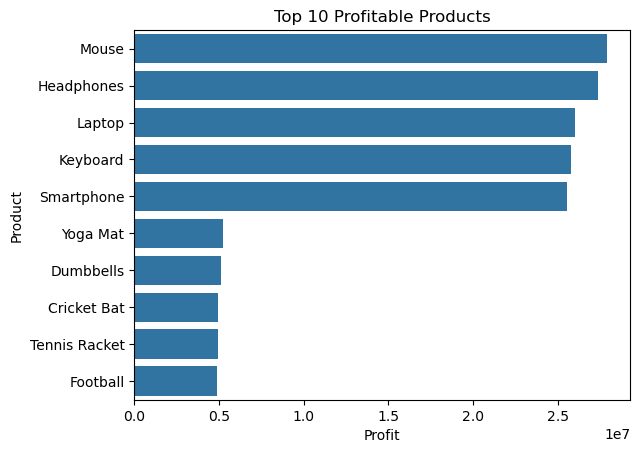

In [ ]:
top_profit = DB.groupby("Product")["Profit"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_profit.values, y=top_profit.index)
plt.title("Top 10 Profitable Products")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.show()

In [ ]:
DB["Age_Group"] = pd.cut(DB["Age"], bins=[0,18,25,35,50,100],
                         labels=["<18","18-25","26-35","36-50","50+"])
age_orders = DB["Age_Group"].value_counts().sort_index()

print(age_orders)

Age_Group
<18       1048
18-25     7444
26-35    10691
36-50    15875
50+      14942
Name: count, dtype: int64


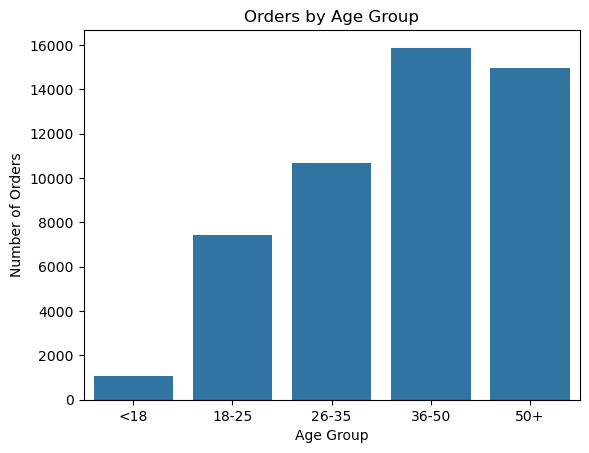

In [ ]:
sns.countplot(x="Age_Group", data=DB, order=age_orders.index)
plt.title("Orders by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.show()